# Hierarchical MARL System â€” Risk-Profile Architecture with Concurrent Training
## Manager-Worker Hierarchy + Beta Classification + Walk-Forward + Ablation

**Author**: Radheshyam Subedi | **Student ID**: U2829927 | **Date**: 04 Mar 2026

This notebook implements the **re-architected** Hierarchical Multi-Agent Reinforcement Learning system:
1. **45 S&P 500 stocks**  re-classified by **historical Beta** into Risk-Profile pools
2. **3 Risk-Profile Workers**  Safe (Î²<0.8), Neutral (0.8<Î²<1.2), Risky (Î²>1.2)
3. **Specialized Reward Functions**  each Worker profile has a mathematically divergent objective
4. **Manager-Worker Communication**  Manager observes Worker cumulative returns + volatility
5. **Concurrent Training**  all 4 agents step and backpropagate simultaneously
6. **10-K Lexical Matrix**  TF-IDF cosine similarity from SEC EDGAR filings

### Risk-Profile Reward Functions
| Profile | Formula | Focus |
|---------|---------|-------|
| **Safe** | $R_{log} - \\lambda(w^TSw) - 2.0 \\cdot \\sigma_{port}$ | Low Variance |
| **Neutral** | $R_{log} - \\lambda(w^TSw) - \\gamma \\cdot Turnover$ | Sharpe Focus |
| **Risky** | $1.5 \\cdot R_{log} - 0.5 \\cdot \\lambda(w^TSw)$ | Alpha/Returns |

In [2]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings, json, time
warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
print("Libraries loaded.")

Libraries loaded.


---
## Section 1: Data Loading & Risk-Profile Classification

We load the pre-computed data and **re-classify stocks by historical Beta** instead of GICS sectors.
- **Beta < 0.8**  Safe Worker Pool (defensive, low-volatility)
- **0.8 < Beta < 1.2** Neutral Worker Pool (market-tracking)
- **Beta > 1.2**  Risky Worker Pool (high-growth, high-volatility)

In [3]:
# Load pre-computed data
price_df = pd.read_csv("data/sp500_50_prices.csv", index_col=0, parse_dates=True)
lexical_df = pd.read_csv("data/processed/lexical_matrix_50.csv", index_col=0)
with open("data/processed/sector_map_50.json") as f:
    sector_map = json.load(f)

tickers = list(price_df.columns)
n_stocks = len(tickers)
print(f"Stocks: {n_stocks}")
print(f"Date range: {price_df.index[0].date()} to {price_df.index[-1].date()}")
print(f"Trading days: {len(price_df)}")
print(f"Lexical matrix shape: {lexical_df.shape}")

Stocks: 45
Date range: 2015-01-02 to 2023-12-29
Trading days: 2264
Lexical matrix shape: (45, 45)


### Historical Beta Calculation

Beta measures a stock's sensitivity to overall market movements:
$$\\beta_i = \\frac{Cov(R_i, R_m)}{Var(R_m)}$$

We use the equal-weight average of all 45 stocks as the market proxy.

=== Risk-Profile Classification ===

Safe Pool (12 stocks, avg Î²=0.669):
  BAX: Î²=0.693 (GICS: Healthcare)
  BMY: Î²=0.555 (GICS: Healthcare)
  COR: Î²=0.709 (GICS: Healthcare)
  D: Î²=0.611 (GICS: Utilities)
  DGX: Î²=0.671 (GICS: Healthcare)
  DPZ: Î²=0.596 (GICS: Consumer Cyclical)
  EVRG: Î²=0.678 (GICS: Utilities)
  LHX: Î²=0.746 (GICS: Industrials)
  MO: Î²=0.579 (GICS: Consumer Defensive)
  NI: Î²=0.694 (GICS: Utilities)
  PPL: Î²=0.752 (GICS: Utilities)
  SRE: Î²=0.741 (GICS: Utilities)

Neutral Pool (25 stocks, avg Î²=0.990):
  AES: Î²=1.103 (GICS: Utilities)
  ANET: Î²=1.164 (GICS: Technology)
  AVB: Î²=0.825 (GICS: Real Estate)
  BK: Î²=1.028 (GICS: Financial Services)
  BR: Î²=0.821 (GICS: Technology)
  CAT: Î²=1.068 (GICS: Industrials)
  CDW: Î²=1.091 (GICS: Technology)
  CNC: Î²=0.928 (GICS: Healthcare)
  CTRA: Î²=0.834 (GICS: Energy)
  DIS: Î²=0.977 (GICS: Communication Services)
  EL: Î²=1.011 (GICS: Consumer Defensive)
  EMR: Î²=1.091 (GICS: Industrials)
  FFIV: Î²=0

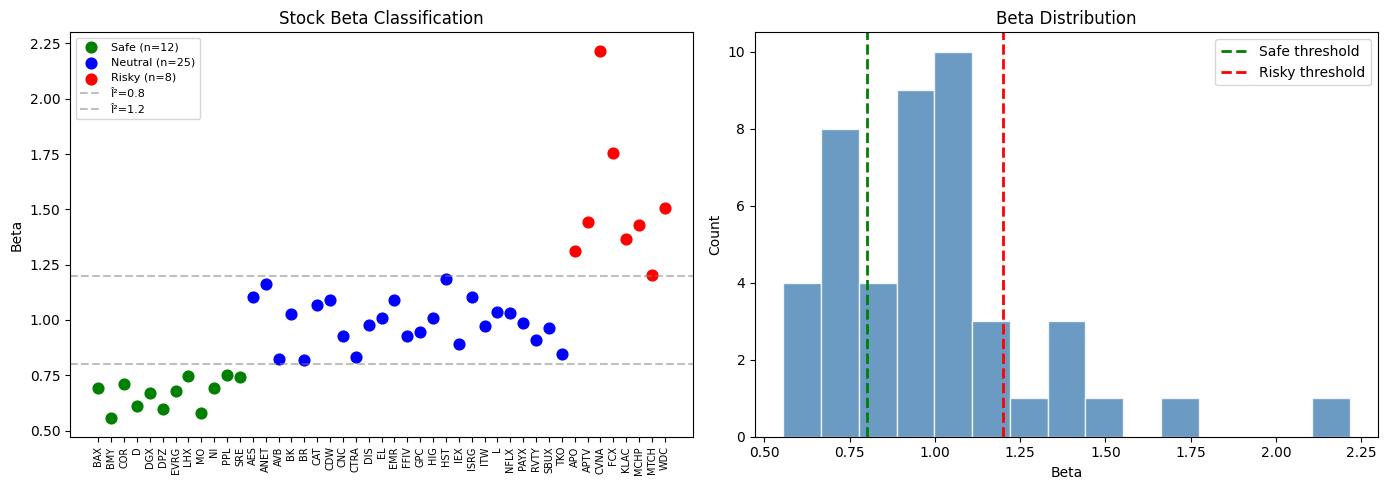

In [4]:
# Calculate daily returns
returns_df = price_df.pct_change().dropna()

# Market proxy: equal-weight average of all stocks
market_returns = returns_df.mean(axis=1)

# Calculate Beta for each ticker
betas = {}
market_var = market_returns.var()
for ticker in tickers:
    cov = returns_df[ticker].cov(market_returns)
    betas[ticker] = cov / (market_var + 1e-10)

beta_df = pd.DataFrame({'Ticker': list(betas.keys()), 'Beta': list(betas.values())})
beta_df = beta_df.sort_values('Beta').reset_index(drop=True)

# Classify into risk pools
risk_pools = {'Safe': [], 'Neutral': [], 'Risky': []}
beta_labels = {}
for ticker, beta in betas.items():
    if beta < 0.8:
        risk_pools['Safe'].append(ticker)
        beta_labels[ticker] = 'Safe'
    elif beta <= 1.2:
        risk_pools['Neutral'].append(ticker)
        beta_labels[ticker] = 'Neutral'
    else:
        risk_pools['Risky'].append(ticker)
        beta_labels[ticker] = 'Risky'

print("=== Risk-Profile Classification ===")
for profile, pool_tickers in risk_pools.items():
    pool_betas = [betas[t] for t in pool_tickers]
    print(f"\n{profile} Pool ({len(pool_tickers)} stocks, avg Î²={np.mean(pool_betas):.3f}):")
    for t in sorted(pool_tickers):
        print(f"  {t}: Î²={betas[t]:.3f} (GICS: {sector_map.get(t, 'N/A')})")

# Beta distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_map = {'Safe': 'green', 'Neutral': 'blue', 'Risky': 'red'}
for profile, pool_tickers in risk_pools.items():
    pool_betas = [betas[t] for t in pool_tickers]
    axes[0].scatter(pool_tickers, pool_betas, c=colors_map[profile], label=f'{profile} (n={len(pool_tickers)})', s=60)
axes[0].axhline(0.8, color='grey', linestyle='--', alpha=0.5, label='Î²=0.8')
axes[0].axhline(1.2, color='grey', linestyle='--', alpha=0.5, label='Î²=1.2')
axes[0].set_ylabel('Beta')
axes[0].set_title('Stock Beta Classification')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].legend(fontsize=8)

all_betas = list(betas.values())
axes[1].hist(all_betas, bins=15, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0.8, color='green', linestyle='--', linewidth=2, label='Safe threshold')
axes[1].axvline(1.2, color='red', linestyle='--', linewidth=2, label='Risky threshold')
axes[1].set_xlabel('Beta')
axes[1].set_ylabel('Count')
axes[1].set_title('Beta Distribution')
axes[1].legend()
plt.tight_layout()
plt.show()

### 10-K Lexical Similarity Matrix Analysis

The lexical matrix captures **structural business similarity** from SEC 10-K filings.
Now indexed by Risk-Profile pools rather than GICS sectors.

Lexical Similarity Statistics:
  Mean: 0.0768
  Std:  0.0742
  Min:  0.0000
  Max:  0.6193
  Safe pool avg intra-similarity: 0.1039
  Neutral pool avg intra-similarity: 0.0848
  Risky pool avg intra-similarity: 0.0568

Text Sources:
  Yahoo: 32 stocks
  10-K: 13 stocks


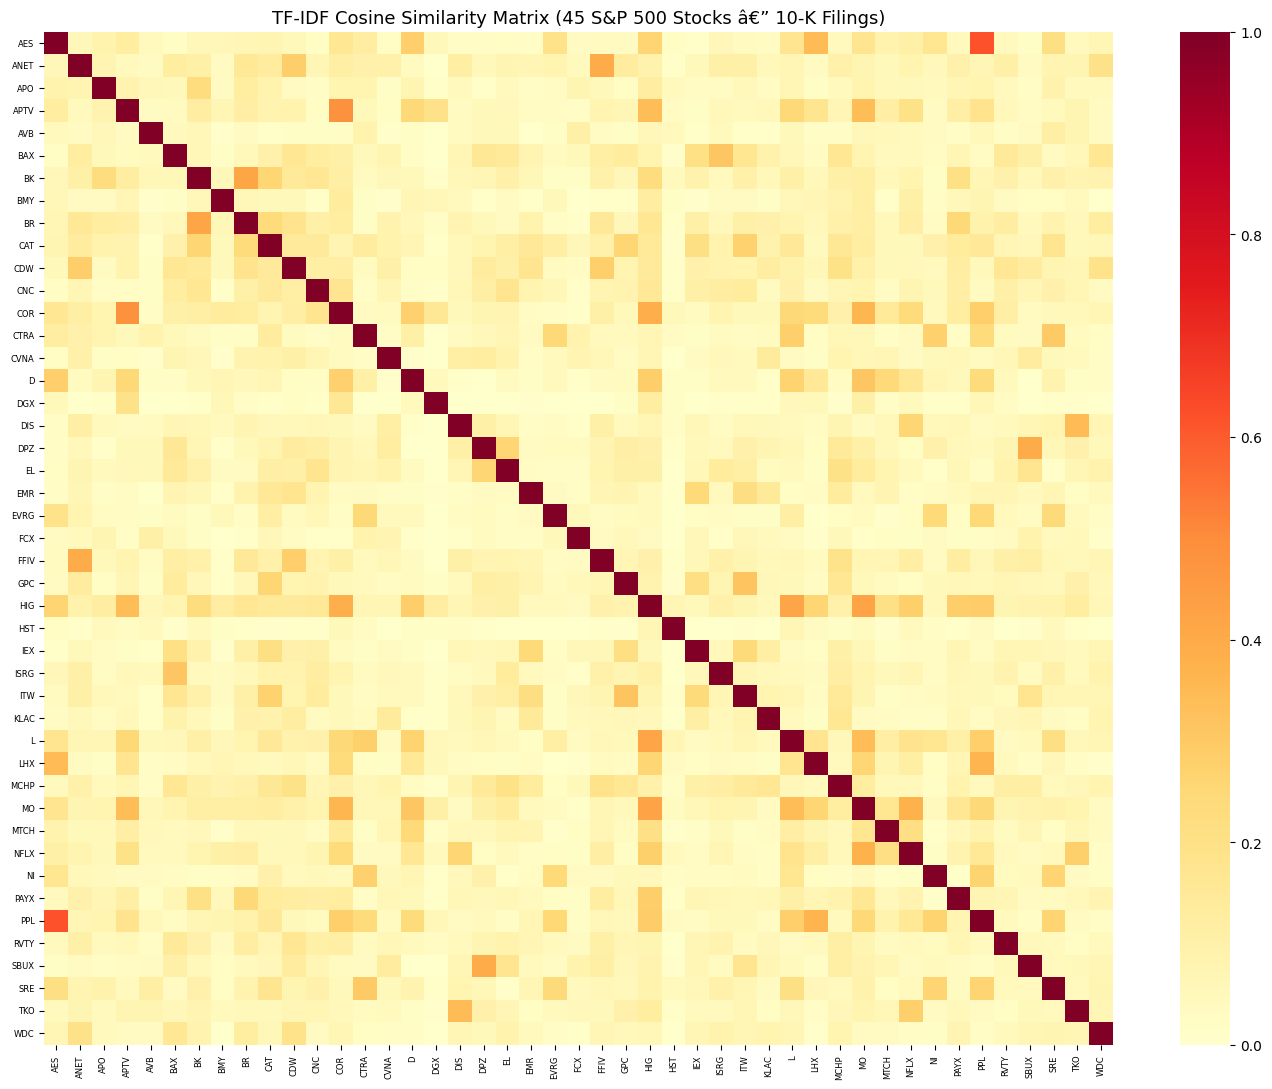

In [5]:
# Lexical matrix statistics
upper = lexical_df.values[np.triu_indices_from(lexical_df.values, k=1)]
print(f"Lexical Similarity Statistics:")
print(f"  Mean: {np.mean(upper):.4f}")
print(f"  Std:  {np.std(upper):.4f}")
print(f"  Min:  {np.min(upper):.4f}")
print(f"  Max:  {np.max(upper):.4f}")

# Per-pool lexical similarity
for profile, pool_tickers in risk_pools.items():
    valid_t = [t for t in pool_tickers if t in lexical_df.index]
    if len(valid_t) > 1:
        sub = lexical_df.loc[valid_t, valid_t].values
        pool_upper = sub[np.triu_indices_from(sub, k=1)]
        print(f"  {profile} pool avg intra-similarity: {np.mean(pool_upper):.4f}")

# Check text sources
with open("data/sp500_50_10k_texts.json") as f:
    text_data = json.load(f)
src_counts = Counter(text_data["sources"].values())
print(f"\nText Sources:")
for src, cnt in src_counts.most_common():
    print(f"  {src}: {cnt} stocks")

# Heatmap
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(lexical_df, cmap='YlOrRd', ax=ax, xticklabels=True, yticklabels=True)
ax.set_title("TF-IDF Cosine Similarity Matrix (45 S&P 500 Stocks â€” 10-K Filings)", fontsize=13)
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

---
## Section 2: Risk-Profile Hierarchical Architecture

### The Hierarchy



### Why Risk-Profile Workers?

| Level | Agent | Manages | Objective |
|-------|-------|---------|-----------|
| **Top** | Manager | Capital allocation to risk profiles | **Global portfolio return** |
| **Bottom** | Safe Worker | Low-beta stock selection | **Minimize variance** |
| **Bottom** | Neutral Worker | Market-beta stock selection | **Maximize Sharpe** |
| **Bottom** | Risky Worker | High-beta stock selection | **Maximize alpha** |

### Final Portfolio Return
$$R_{global} = v_{safe} \\cdot R_{safe} + v_{neutral} \\cdot R_{neutral} + v_{risky} \\cdot R_{risky}$$

### Worker Environment — Profile-Specialized Rewards + Cash Asset
Each Worker manages stocks within its **risk-profile pool** plus a **Cash asset** (risk-free).
The Cash asset breaks the 1/N trap by giving agents an explicit "do nothing" option.
Weights are sampled via **Dirichlet distribution** instead of softmax to allow skewed allocations.

In [6]:
class WorkerEnv(gym.Env):
    """Worker agent: picks stocks within a risk-profile pool + Cash asset.
    
    Key fixes for 1/N convergence:
      1. Cash asset (action dim = n_assets + 1) — absorbs unused allocation
      2. Weights from Dirichlet sampling (in training loop) instead of softmax
      3. Hard turnover clipping (max 0.3 per step)
    """
    metadata = {"render_modes": []}
    TURNOVER_LIMIT = 0.3
    
    def __init__(self, price_df, lexical_matrix, tickers, profile="neutral",
                 window_size=30, lambda_penalty=0.1, gamma_penalty=0.01):
        super().__init__()
        self.profile = profile
        self.tickers = [t for t in tickers if t in price_df.columns and t in lexical_matrix.index]
        self.n_assets = len(self.tickers)
        self.n_total = self.n_assets + 1  # +1 for Cash
        self.prices = price_df[self.tickers].values
        self.returns_matrix = np.diff(self.prices, axis=0) / (self.prices[:-1] + 1e-8)
        self.lexical_matrix = np.nan_to_num(
            lexical_matrix.loc[self.tickers, self.tickers].values, nan=0.0)
        self.window_size = window_size
        self.lambda_penalty = lambda_penalty
        self.gamma_penalty = gamma_penalty
        
        if len(self.returns_matrix) > 1:
            self.cov_matrix = np.cov(self.returns_matrix.T)
        else:
            self.cov_matrix = np.eye(self.n_assets) * 0.01
        
        obs_dim = window_size * self.n_assets + self.n_total
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(low=0.01, high=10.0, shape=(self.n_total,), dtype=np.float32)
        
        self.current_step = 0
        self.portfolio_weights = np.ones(self.n_total) / self.n_total
        self.max_steps = len(self.prices) - window_size - 1
        self.portfolio_value = 1.0
        self.cum_return = 0.0
        self.recent_returns = []
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.portfolio_weights = np.ones(self.n_total) / self.n_total
        self.portfolio_value = 1.0
        self.cum_return = 0.0
        self.recent_returns = []
        return self._get_obs(), {}
    
    def step(self, action):
        w_full = np.abs(action) + 1e-8
        w_full = w_full / np.sum(w_full)
        
        # Hard turnover clipping
        delta = w_full - self.portfolio_weights
        turnover = np.sum(np.abs(delta))
        if turnover > self.TURNOVER_LIMIT:
            delta = delta * (self.TURNOVER_LIMIT / turnover)
            w_full = self.portfolio_weights + delta
            w_full = np.maximum(w_full, 0.0)
            w_full = w_full / np.sum(w_full)
            turnover = self.TURNOVER_LIMIT
        
        w_stocks = w_full[:self.n_assets]
        w_cash = w_full[self.n_assets]
        
        curr = self.prices[self.current_step]
        nxt = self.prices[self.current_step + 1]
        pr = nxt / (curr + 1e-8)
        stock_ret = np.dot(w_stocks, pr)
        port_ret = max(stock_ret + w_cash * 1.0, 1e-8)
        log_ret = np.log(port_ret)
        
        if np.sum(w_stocks) > 1e-8:
            w_norm = w_stocks / (np.sum(w_stocks) + 1e-8)
            sem_pen = np.dot(w_norm.T, np.dot(self.lexical_matrix, w_norm))
        else:
            sem_pen = 0.0
        
        if self.profile == "safe":
            if np.sum(w_stocks) > 1e-8:
                w_norm = w_stocks / (np.sum(w_stocks) + 1e-8)
                port_vol = np.sqrt(max(np.dot(w_norm.T, np.dot(self.cov_matrix, w_norm)), 1e-10))
            else:
                port_vol = 0.0
            reward = float(log_ret - self.lambda_penalty * sem_pen - 2.0 * port_vol)
        elif self.profile == "risky":
            reward = float(1.5 * log_ret - 0.5 * self.lambda_penalty * sem_pen)
        else:
            reward = float(log_ret - self.lambda_penalty * sem_pen - self.gamma_penalty * turnover)
        
        self.portfolio_weights = w_full
        self.portfolio_value *= port_ret
        self.cum_return += (port_ret - 1.0)
        self.recent_returns.append(port_ret - 1.0)
        if len(self.recent_returns) > 30:
            self.recent_returns.pop(0)
        self.current_step += 1
        terminated = self.current_step >= self.max_steps
        return self._get_obs(), reward, terminated, False, {
            'portfolio_return': port_ret, 'semantic_penalty': sem_pen,
            'turnover': turnover, 'weights': w_full.copy(),
            'stock_weights': w_stocks.copy(), 'cash_weight': w_cash,
            'cum_return': self.cum_return,
            'volatility': float(np.std(self.recent_returns)) if len(self.recent_returns) > 1 else 0.0}
    
    def _get_obs(self):
        s = self.current_step - self.window_size
        win = self.prices[s:self.current_step]
        norm = win / (win[0, :] + 1e-8)
        return np.concatenate([norm.flatten(), self.portfolio_weights]).astype(np.float32)
    
    def get_worker_state(self):
        """Return [cum_return, volatility] for Manager observation."""
        vol = float(np.std(self.recent_returns)) if len(self.recent_returns) > 1 else 0.0
        return np.array([self.cum_return, vol], dtype=np.float32)

print("WorkerEnv defined (Dirichlet + Cash + turnover clipping).")

WorkerEnv defined (Dirichlet + Cash + turnover clipping).


### Manager Environment â” Worker-Aware Observation
The Manager now observes **global market features** plus each Worker's **cumulative return** and **volatility**. It outputs a capital allocation vector V = [v_safe, v_neutral, v_risky].

In [7]:
class ManagerEnv(gym.Env):
    """Manager agent: allocates capital across 3 risk-profile Workers.
    
    Observation: [market_window(30Ã—3), current_allocation(3), 
                  worker_cum_returns(3), worker_volatilities(3)]
    Action: V = [v_safe, v_neutral, v_risky]
    Reward: Global portfolio return (weighted sum of Worker returns)
    """
    metadata = {"render_modes": []}
    
    def __init__(self, price_df, lexical_matrix, risk_pools, window_size=30):
        super().__init__()
        self.risk_pools = risk_pools
        self.pool_names = ['Safe', 'Neutral', 'Risky']
        self.n_pools = 3
        
        # Pool-level price index (average of pool stocks)
        self.pool_prices = {}
        for name in self.pool_names:
            pool_tickers = [t for t in risk_pools.get(name, []) if t in price_df.columns]
            if pool_tickers:
                self.pool_prices[name] = price_df[pool_tickers].mean(axis=1).values
            else:
                self.pool_prices[name] = np.ones(len(price_df))
        
        self.window_size = window_size
        self.all_prices = np.column_stack([self.pool_prices[p] for p in self.pool_names])
        
        # Intra-pool lexical similarity
        self.pool_sim = np.zeros(self.n_pools)
        for i, name in enumerate(self.pool_names):
            pool_tickers = [t for t in risk_pools.get(name, []) if t in lexical_matrix.index]
            if len(pool_tickers) > 1:
                sim = lexical_matrix.loc[pool_tickers, pool_tickers].values
                mask = np.triu(np.ones_like(sim, dtype=bool), k=1)
                self.pool_sim[i] = np.nanmean(sim[mask])
        
        # obs = market_window(30*3) + allocation(3) + worker_cum_returns(3) + worker_vols(3)
        obs_dim = window_size * self.n_pools + self.n_pools + self.n_pools + self.n_pools
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(self.n_pools,), dtype=np.float32)
        
        self.current_step = 0
        self.pool_weights = np.ones(self.n_pools) / self.n_pools
        self.max_steps = len(self.all_prices) - window_size - 1
        # Worker state placeholders (updated by concurrent training loop)
        self.worker_cum_returns = np.zeros(self.n_pools, dtype=np.float32)
        self.worker_volatilities = np.zeros(self.n_pools, dtype=np.float32)
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.pool_weights = np.ones(self.n_pools) / self.n_pools
        self.worker_cum_returns = np.zeros(self.n_pools, dtype=np.float32)
        self.worker_volatilities = np.zeros(self.n_pools, dtype=np.float32)
        return self._get_obs(), {}
    
    def update_worker_states(self, worker_states):
        """Called by training loop to inject Worker cum_returns and volatilities."""
        for i, name in enumerate(self.pool_names):
            if name in worker_states:
                self.worker_cum_returns[i] = worker_states[name][0]
                self.worker_volatilities[i] = worker_states[name][1]
    
    def step(self, action, worker_returns=None):
        # action = raw weights (sampled from Dirichlet in training loop)
        v = np.abs(action) + 1e-8
        v = v / np.sum(v)
        
        if worker_returns is not None:
            # Concurrent mode: global return = weighted sum of Worker returns
            global_ret = sum(v[i] * worker_returns.get(name, 1.0) 
                           for i, name in enumerate(self.pool_names))
            global_ret = max(global_ret, 1e-8)
        else:
            # Fallback: use pool-level prices
            curr = self.all_prices[self.current_step]
            nxt = self.all_prices[self.current_step + 1]
            pr = nxt / (curr + 1e-8)
            global_ret = max(np.dot(v, pr), 1e-8)
        
        log_ret = np.log(global_ret)
        turnover = np.sum(np.abs(v - self.pool_weights))
        reward = float(log_ret - 0.01 * turnover)
        
        self.pool_weights = v
        self.current_step += 1
        terminated = self.current_step >= self.max_steps
        return self._get_obs(), reward, terminated, False, {
            'pool_weights': v.copy(), 'global_return': global_ret}
    
    def _get_obs(self):
        s = self.current_step - self.window_size
        win = self.all_prices[s:self.current_step]
        norm = win / (win[0, :] + 1e-8)
        return np.concatenate([
            norm.flatten(), self.pool_weights,
            self.worker_cum_returns, self.worker_volatilities
        ]).astype(np.float32)

print("ManagerEnv defined (Worker-aware observation).")

ManagerEnv defined (Worker-aware observation).


---
## Section 3: EIIE Network & Concurrent REINFORCE Training

The **EIIE** (Ensemble of Identical Independent Evaluators) network:
- Shares Conv1D weights across assets and prevents ticker memorization
- Includes **Portfolio-Vector Memory** (PVM)
- Each of the 4 agents (Manager + 3 Workers) has its own EIIE instance

### Concurrent Training Loop
All 4 agents step simultaneously at each timestep. The Manager observes Worker states
and outputs capital allocation V. Workers focus on their local pool objectives.

In [8]:
class EIIENetwork(nn.Module):
    """EIIE with shared Conv1D weights + Portfolio-Vector Memory.
    
    Output: Dirichlet concentration parameters (alpha > 0) via Softplus + 1.
    This replaces the old softmax output which caused 1/N convergence.
    """
    def __init__(self, n_assets, window_size, n_price_assets=None):
        super().__init__()
        self.n_assets = n_assets  # output dimension (includes Cash for Workers)
        self.n_price_assets = n_price_assets or n_assets  # price window assets (no Cash)
        self.conv1 = nn.Conv1d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(self.n_price_assets * 32 + n_assets, 64)
        self.fc2 = nn.Linear(64, n_assets)
    
    def forward(self, pw, pvm):
        feats = []
        for i in range(self.n_price_assets):
            x = pw[:, i, :].unsqueeze(1)
            x = F.relu(self.conv1(x))
            x = F.relu(self.conv2(x))
            x = x.mean(dim=2)
            feats.append(x)
        c = torch.cat(feats + [pvm], dim=1)
        x = F.relu(self.fc1(c))
        # Dirichlet concentration params: Softplus + 1.0 ensures alpha > 1
        # alpha > 1 gives unimodal Dirichlet (peaks away from uniform)
        return F.softplus(self.fc2(x)) + 1.0

print("EIIENetwork defined (Dirichlet alpha output via Softplus+1).")

EIIENetwork defined (Dirichlet alpha output via Softplus+1).


In [9]:
def train_concurrent(manager_env, worker_envs, n_episodes=200, lr=3e-3,
                     max_steps=200, verbose=False):
    """Concurrent training with Dirichlet + scheduled hyperparameters.
    
    Schedules (to break 1/N convergence):
      - LR:       3e-3 -> 5e-4 (cosine decay)
      - Entropy:  0.05 -> 0.005 (linear decay: explore early, exploit late)
      - Turnover: 1.0  -> 0.3  (unrestricted early, tighten late)
    """
    pool_names = ['Safe', 'Neutral', 'Risky']
    
    m_n = manager_env.action_space.shape[0]
    m_ws = manager_env.window_size
    manager_net = EIIENetwork(m_n, m_ws)
    manager_opt = optim.Adam(manager_net.parameters(), lr=lr)
    m_scheduler = optim.lr_scheduler.CosineAnnealingLR(manager_opt, T_max=n_episodes, eta_min=5e-4)
    
    worker_nets, worker_opts, worker_schedulers = {}, {}, {}
    for name in pool_names:
        if name in worker_envs:
            env = worker_envs[name]
            worker_nets[name] = EIIENetwork(env.n_total, env.window_size, n_price_assets=env.n_assets)
            worker_opts[name] = optim.Adam(worker_nets[name].parameters(), lr=lr)
            worker_schedulers[name] = optim.lr_scheduler.CosineAnnealingLR(
                worker_opts[name], T_max=n_episodes, eta_min=5e-4)
    
    hist = {'manager_rewards': [], 'worker_rewards': {n: [] for n in pool_names},
            'global_returns': [], 'allocations': []}
    
    for ep in range(n_episodes):
        progress = ep / max(n_episodes - 1, 1)
        entropy_bonus = 0.05 * (1.0 - progress) + 0.005 * progress
        turnover_limit = 1.0 * (1.0 - progress) + 0.3 * progress
        for name in pool_names:
            if name in worker_envs:
                worker_envs[name].TURNOVER_LIMIT = turnover_limit
        
        m_obs, _ = manager_env.reset()
        w_obs = {}
        for name in pool_names:
            if name in worker_envs:
                w_obs[name], _ = worker_envs[name].reset()
        
        m_lps, m_rews, m_entropies = [], [], []
        w_lps = {n: [] for n in pool_names}
        w_rews = {n: [] for n in pool_names}
        w_entropies = {n: [] for n in pool_names}
        done, steps = False, 0
        
        while not done and steps < max_steps:
            worker_states = {}
            for name in pool_names:
                if name in worker_envs:
                    worker_states[name] = worker_envs[name].get_worker_state()
            manager_env.update_worker_states(worker_states)
            m_obs = manager_env._get_obs()
            
            obs_dim = m_ws * m_n
            m_pw = torch.FloatTensor(m_obs[:obs_dim].reshape(m_n, m_ws)).unsqueeze(0)
            m_pvm = torch.FloatTensor(m_obs[obs_dim:obs_dim+m_n]).unsqueeze(0)
            m_alpha = manager_net(m_pw, m_pvm).squeeze()
            m_alpha = torch.clamp(m_alpha, min=0.1, max=100.0)
            m_dist = torch.distributions.Dirichlet(m_alpha)
            m_action = m_dist.sample()
            m_lps.append(m_dist.log_prob(m_action))
            m_entropies.append(m_dist.entropy())
            
            worker_returns = {}
            for name in pool_names:
                if name not in worker_envs:
                    continue
                env = worker_envs[name]
                net = worker_nets[name]
                obs = w_obs[name]
                w_obs_dim = env.window_size * env.n_assets
                w_pw = torch.FloatTensor(obs[:w_obs_dim].reshape(env.n_assets, env.window_size)).unsqueeze(0)
                w_pvm = torch.FloatTensor(obs[w_obs_dim:w_obs_dim+env.n_total]).unsqueeze(0)
                w_alpha = net(w_pw, w_pvm).squeeze()
                w_alpha = torch.clamp(w_alpha, min=0.1, max=100.0)
                w_dist = torch.distributions.Dirichlet(w_alpha)
                w_action = w_dist.sample()
                w_lps[name].append(w_dist.log_prob(w_action))
                w_entropies[name].append(w_dist.entropy())
                
                obs_new, w_reward, w_term, _, w_info = env.step(w_action.detach().numpy())
                w_obs[name] = obs_new
                w_rews[name].append(w_reward)
                worker_returns[name] = w_info.get('portfolio_return', 1.0)
                if w_term:
                    done = True
            
            m_obs_new, m_reward, m_term, _, m_info = manager_env.step(
                m_action.detach().numpy(), worker_returns=worker_returns)
            m_obs = m_obs_new
            m_rews.append(m_reward)
            if m_term:
                done = True
            steps += 1
        
        # REINFORCE + scheduled entropy bonus
        gamma = 0.99
        G, rets = 0, []
        for r in reversed(m_rews):
            G = r + gamma * G
            rets.insert(0, G)
        rets = torch.FloatTensor(rets)
        if len(rets) > 1:
            rets = (rets - rets.mean()) / (rets.std() + 1e-8)
        if m_lps:
            policy_loss = sum(-lp * G for lp, G in zip(m_lps, rets))
            ent_loss = -entropy_bonus * sum(m_entropies)
            (policy_loss + ent_loss).backward()
            torch.nn.utils.clip_grad_norm_(manager_net.parameters(), 1.0)
            manager_opt.step(); manager_opt.zero_grad()
        m_scheduler.step()
        
        for name in pool_names:
            if name not in worker_nets or not w_lps[name]:
                continue
            G, rets = 0, []
            for r in reversed(w_rews[name]):
                G = r + gamma * G
                rets.insert(0, G)
            rets = torch.FloatTensor(rets)
            if len(rets) > 1:
                rets = (rets - rets.mean()) / (rets.std() + 1e-8)
            policy_loss = sum(-lp * G for lp, G in zip(w_lps[name], rets))
            ent_loss = -entropy_bonus * sum(w_entropies[name])
            (policy_loss + ent_loss).backward()
            torch.nn.utils.clip_grad_norm_(worker_nets[name].parameters(), 1.0)
            worker_opts[name].step(); worker_opts[name].zero_grad()
            worker_schedulers[name].step()
        
        hist['manager_rewards'].append(sum(m_rews))
        hist['global_returns'].append(float(m_info.get('global_return', 1.0)) if m_info else 1.0)
        for name in pool_names:
            hist['worker_rewards'][name].append(sum(w_rews[name]) if w_rews[name] else 0)
        if m_info and 'pool_weights' in m_info:
            hist['allocations'].append(m_info['pool_weights'].tolist())
        
        if verbose and (ep+1) % 20 == 0:
            alloc_str = ""
            if hist['allocations']:
                alloc = hist['allocations'][-1]
                alloc_str = f" | V=[{alloc[0]:.2f},{alloc[1]:.2f},{alloc[2]:.2f}]"
            lr_now = manager_opt.param_groups[0]['lr']
            print(f"  Ep {ep+1:3d} | R={sum(m_rews):+.3f}{alloc_str}"
                  f" | lr={lr_now:.5f} ent={entropy_bonus:.4f} TO={turnover_limit:.2f}"
                  f" | S={sum(w_rews.get('Safe',[])):+.3f}"
                  f" N={sum(w_rews.get('Neutral',[])):+.3f}"
                  f" R={sum(w_rews.get('Risky',[])):+.3f}")
    
    return manager_net, worker_nets, hist

print("Training defined (Dirichlet + LR/entropy/turnover schedules).")

Training defined (Dirichlet + LR/entropy/turnover schedules).


---
## Section 4: Risk Metrics

### CVaR (Conditional Value at Risk) at 95%
$$CVaR_{95\%} = E[R \mid R \leq VaR_{95\%}]$$

### Sortino Ratio
$$Sortino = \\frac{\\bar{R}}{\\sigma_{downside}}$$

### Calmar Ratio
$$Calmar = \\frac{R_{annualized}}{MaxDrawdown}$$

In [10]:
def compute_max_drawdown(returns):
    cum = np.cumprod(1 + returns)
    peak = np.maximum.accumulate(cum)
    dd = (peak - cum) / peak
    return float(np.max(dd)) if len(dd) > 0 else 0.0

def compute_cvar(returns, alpha=0.05):
    sorted_r = np.sort(returns)
    cutoff = max(int(alpha * len(sorted_r)), 1)
    return float(np.mean(sorted_r[:cutoff]))

def compute_sortino(returns, target=0):
    excess = returns - target
    downside = returns[returns < target]
    if len(downside) == 0: return float('inf')
    return float(np.mean(excess) / (np.std(downside) + 1e-8))

def compute_calmar(returns, max_dd=None):
    if max_dd is None: max_dd = compute_max_drawdown(returns)
    ann_ret = np.mean(returns) * 252
    return float(ann_ret / max_dd) if max_dd > 0 else 0.0

def compute_hhi(weights):
    return float(np.sum(weights ** 2))

def compute_effective_n(weights):
    hhi = compute_hhi(weights)
    return float(1.0 / hhi) if hhi > 0 else 0.0

def drawdown_decomposition(returns):
    cum = np.cumprod(1 + returns)
    peak = np.maximum.accumulate(cum)
    dd = (peak - cum) / peak
    drawdowns = []
    in_dd, dd_start, max_depth, trough_idx = False, 0, 0, 0
    for i in range(len(dd)):
        if dd[i] > 0.001:
            if not in_dd:
                dd_start, in_dd, max_depth, trough_idx = i, True, dd[i], i
            elif dd[i] > max_depth:
                max_depth, trough_idx = dd[i], i
        else:
            if in_dd:
                drawdowns.append({'start': dd_start, 'trough': trough_idx, 'end': i,
                    'depth': float(max_depth), 'duration': i - dd_start, 'recovery': i - trough_idx})
                in_dd = False
    if in_dd:
        drawdowns.append({'start': dd_start, 'trough': trough_idx, 'end': len(dd)-1,
            'depth': float(max_depth), 'duration': len(dd)-1-dd_start, 'recovery': len(dd)-1-trough_idx})
    return drawdowns

def dirichlet_mode(alpha):
    """Compute mode of Dirichlet: (alpha_i - 1) / (sum(alpha) - K) for alpha_i > 1.
    Falls back to mean if any alpha_i <= 1."""
    K = len(alpha)
    if np.all(alpha > 1.0) and np.sum(alpha) > K:
        return (alpha - 1.0) / (np.sum(alpha) - K)
    else:
        return alpha / np.sum(alpha)  # Fallback to mean

def evaluate_concurrent(manager_env, worker_envs, manager_net, worker_nets, max_steps=200):
    """Evaluate using Dirichlet MODE (concentrated) not mean (uniform)."""
    pool_names = ['Safe', 'Neutral', 'Risky']
    m_obs, _ = manager_env.reset()
    w_obs = {}
    for name in pool_names:
        if name in worker_envs:
            w_obs[name], _ = worker_envs[name].reset()
    
    global_returns, worker_returns_hist = [], {n: [] for n in pool_names}
    allocations, done, steps = [], False, 0
    m_n = manager_env.action_space.shape[0]
    m_ws = manager_env.window_size
    
    while not done and steps < max_steps:
        worker_states = {}
        for name in pool_names:
            if name in worker_envs:
                worker_states[name] = worker_envs[name].get_worker_state()
        manager_env.update_worker_states(worker_states)
        m_obs = manager_env._get_obs()
        
        obs_dim = m_ws * m_n
        m_pw = torch.FloatTensor(m_obs[:obs_dim].reshape(m_n, m_ws)).unsqueeze(0)
        m_pvm = torch.FloatTensor(m_obs[obs_dim:obs_dim+m_n]).unsqueeze(0)
        with torch.no_grad():
            m_alpha = manager_net(m_pw, m_pvm).squeeze().numpy()
            v = dirichlet_mode(m_alpha)
        
        w_rets = {}
        for name in pool_names:
            if name not in worker_envs:
                continue
            env = worker_envs[name]
            net = worker_nets[name]
            w_n_total = env.n_total
            w_n_price = env.n_assets
            w_ws_l = env.window_size
            obs = w_obs[name]
            w_od = w_ws_l * w_n_price
            w_pw = torch.FloatTensor(obs[:w_od].reshape(w_n_price, w_ws_l)).unsqueeze(0)
            w_pvm = torch.FloatTensor(obs[w_od:w_od+w_n_total]).unsqueeze(0)
            with torch.no_grad():
                w_alpha = net(w_pw, w_pvm).squeeze().numpy()
                w_w = dirichlet_mode(w_alpha)
            obs_new, _, w_term, _, w_info = env.step(w_w)
            w_obs[name] = obs_new
            w_rets[name] = w_info.get('portfolio_return', 1.0)
            worker_returns_hist[name].append(w_rets[name] - 1.0)
            if w_term:
                done = True
        
        m_obs_new, _, m_term, _, m_info = manager_env.step(v, worker_returns=w_rets)
        m_obs = m_obs_new
        
        global_ret = sum(v[i] * w_rets.get(name, 1.0) for i, name in enumerate(pool_names))
        global_returns.append(global_ret - 1.0)
        allocations.append(v.copy())
        
        if m_term:
            done = True
        steps += 1
    
    global_returns = np.array(global_returns)
    avg_alloc = np.mean(allocations, axis=0) if allocations else np.ones(3)/3
    
    result = {
        'global_returns': global_returns,
        'total_return': float(np.prod(1 + global_returns) - 1),
        'sharpe': float(np.mean(global_returns) / (np.std(global_returns) + 1e-8) * np.sqrt(252)),
        'max_drawdown': compute_max_drawdown(global_returns),
        'cvar_95': compute_cvar(global_returns),
        'sortino': compute_sortino(global_returns),
        'calmar': compute_calmar(global_returns),
        'avg_allocation': avg_alloc,
        'worker_results': {}
    }
    for name in pool_names:
        wr = np.array(worker_returns_hist[name]) if worker_returns_hist[name] else np.array([0.0])
        result['worker_results'][name] = {
            'total_return': float(np.prod(1 + wr) - 1),
            'sharpe': float(np.mean(wr) / (np.std(wr) + 1e-8) * np.sqrt(252)),
            'max_drawdown': compute_max_drawdown(wr),
        }
    return result

print("Risk metrics and evaluation functions defined.")

Risk metrics and evaluation functions defined.


---
## Section 5: Concurrent Training â€” 3 Risk-Profile Workers + Manager

Training all 4 agents simultaneously:
1. **Manager** allocates capital across Safe/Neutral/Risky pools
2. **Safe Worker**  minimizes variance in low-beta stocks  
3. **Neutral Worker**  maximizes Sharpe in market-beta stocks
4. **Risky Worker**  maximizes alpha in high-beta stocks

In [11]:
t0 = time.time()

print("=" * 60)
print("CONCURRENT TRAINING: Manager + 3 Risk-Profile Workers")
print("=" * 60)

# Create Worker environments for each risk pool
worker_envs = {}
for profile in ['Safe', 'Neutral', 'Risky']:
    pool_tickers = risk_pools[profile]
    if len(pool_tickers) >= 2:
        worker_envs[profile] = WorkerEnv(
            price_df, lexical_df, pool_tickers,
            profile=profile.lower(), window_size=30,
            lambda_penalty=0.1, gamma_penalty=0.01)
        print(f"  {profile} Worker: {len(pool_tickers)} stocks")
    else:
        print(f"  {profile} Worker: SKIPPED (only {len(pool_tickers)} stocks)")

# Create Manager environment
manager_env = ManagerEnv(price_df, lexical_df, risk_pools, window_size=30)
print(f"  Manager: allocating across {len(worker_envs)} risk pools")

# Concurrent training
manager_net, worker_nets, train_hist = train_concurrent(
    manager_env, worker_envs, n_episodes=200, verbose=True)

print(f"\nAll agents trained concurrently! ({time.time()-t0:.1f}s)")

CONCURRENT TRAINING: Manager + 3 Risk-Profile Workers
  Safe Worker: 12 stocks
  Neutral Worker: 25 stocks
  Risky Worker: 8 stocks
  Manager: allocating across 3 risk pools
  Ep  20 | R=-1.360 | V=[0.11,0.77,0.12] | lr=0.00294 ent=0.0457 TO=0.93 | S=-8.442 N=-4.319 R=-2.547
  Ep  40 | R=-1.387 | V=[0.42,0.47,0.12] | lr=0.00276 ent=0.0412 TO=0.86 | S=-8.307 N=-4.289 R=-2.741
  Ep  60 | R=-1.369 | V=[0.11,0.30,0.59] | lr=0.00248 ent=0.0367 TO=0.79 | S=-8.375 N=-4.208 R=-2.624
  Ep  80 | R=-1.471 | V=[0.21,0.77,0.03] | lr=0.00214 ent=0.0321 TO=0.72 | S=-8.309 N=-4.166 R=-2.465
  Ep 100 | R=-1.470 | V=[0.06,0.22,0.72] | lr=0.00175 ent=0.0276 TO=0.65 | S=-8.228 N=-3.966 R=-2.520
  Ep 120 | R=-1.616 | V=[0.40,0.51,0.09] | lr=0.00136 ent=0.0231 TO=0.58 | S=-8.204 N=-3.835 R=-2.427
  Ep 140 | R=-1.389 | V=[0.26,0.67,0.07] | lr=0.00102 ent=0.0186 TO=0.51 | S=-8.075 N=-3.634 R=-2.403
  Ep 160 | R=-1.475 | V=[0.33,0.49,0.18] | lr=0.00074 ent=0.0140 TO=0.44 | S=-8.027 N=-3.453 R=-2.285
  Ep 180 |

### Concurrent Evaluation
Evaluate the full hierarchy: Manager allocating to Workers, each Worker selecting stocks.

In [12]:
# Evaluate concurrent system
eval_result = evaluate_concurrent(manager_env, worker_envs, manager_net, worker_nets, max_steps=200)

print("=== Global Portfolio ===")
print(f"  Return: {eval_result['total_return']:.4f}")
print(f"  Sharpe: {eval_result['sharpe']:.4f}")
print(f"  MaxDD:  {eval_result['max_drawdown']:.4f}")
print(f"  CVaR:   {eval_result['cvar_95']:.4f}")
print(f"  Sortino: {eval_result['sortino']:.4f}")
print(f"  Calmar: {eval_result['calmar']:.4f}")

print(f"\n=== Manager Allocation ===")
for i, name in enumerate(['Safe', 'Neutral', 'Risky']):
    print(f"  {name}: {eval_result['avg_allocation'][i]:.4f}")

print(f"\n=== Worker Performance ===")
for name, wr in eval_result['worker_results'].items():
    print(f"  {name}: Return={wr['total_return']:.4f}, Sharpe={wr['sharpe']:.4f}, MaxDD={wr['max_drawdown']:.4f}")

=== Global Portfolio ===
  Return: 0.0215
  Sharpe: 0.2595
  MaxDD:  0.1235
  CVaR:   -0.0227
  Sortino: 0.0212
  Calmar: 0.3004

=== Manager Allocation ===
  Safe: 0.0284
  Neutral: 0.9048
  Risky: 0.0668

=== Worker Performance ===
  Safe: Return=0.0667, Sharpe=0.6811, MaxDD=0.0958
  Neutral: Return=0.0350, Sharpe=0.3729, MaxDD=0.1216
  Risky: Return=-0.1750, Sharpe=-1.2344, MaxDD=0.2164


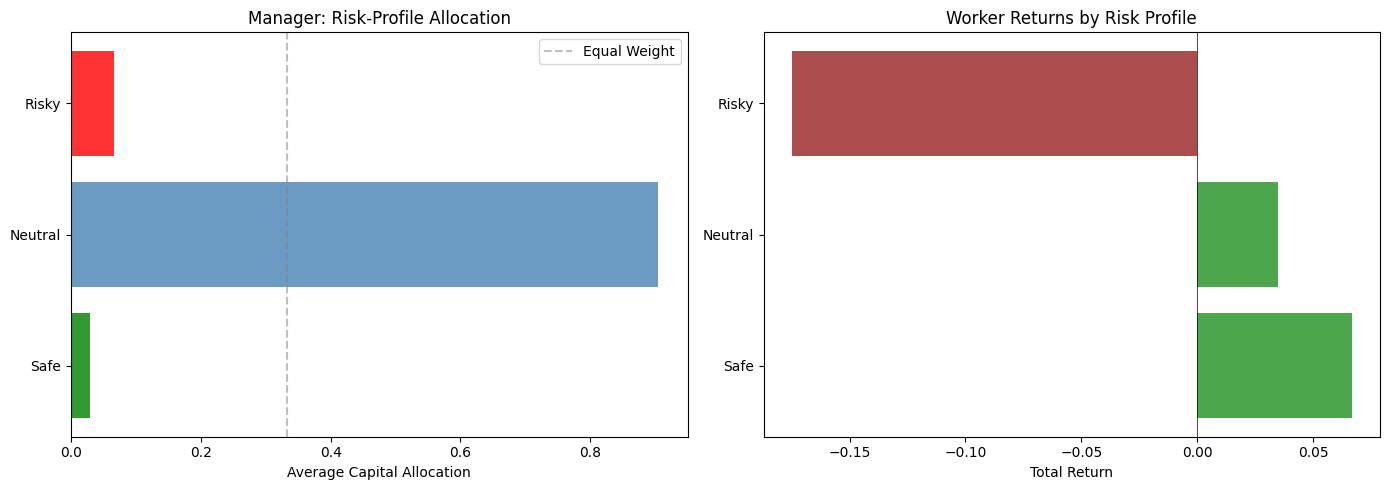

In [13]:
# Manager allocation and Worker returns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pool_names_plot = ['Safe', 'Neutral', 'Risky']
colors_plot = ['green', 'steelblue', 'red']

# Allocation weights
alloc = eval_result['avg_allocation']
axes[0].barh(pool_names_plot, alloc, color=colors_plot, alpha=0.8)
axes[0].axvline(1.0/3, color='grey', linestyle='--', alpha=0.5, label='Equal Weight')
axes[0].set_xlabel('Average Capital Allocation')
axes[0].set_title('Manager: Risk-Profile Allocation')
axes[0].legend()

# Worker returns
w_returns = [eval_result['worker_results'][n]['total_return'] for n in pool_names_plot]
bar_colors = ['green' if r > 0 else 'darkred' for r in w_returns]
axes[1].barh(pool_names_plot, w_returns, color=bar_colors, alpha=0.7)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Total Return')
axes[1].set_title('Worker Returns by Risk Profile')

plt.tight_layout()
plt.show()

---
## Section 6: Walk-Forward Validation

Rolling retrain across 4 market regimes using the concurrent architecture.

In [ ]:
wf_windows = [
    ("2015-2018 2019 (Bull)", "2015-01-01", "2019-01-01", "2019-01-01", "2020-01-01"),
    ("2015-2019 2020 (COVID)", "2015-01-01", "2020-01-01", "2020-01-01", "2021-01-01"),
    ("2015-2020 2021 (Recovery)", "2015-01-01", "2021-01-01", "2021-01-01", "2022-01-01"),
    ("2015-2021 2022 (Bear)", "2015-01-01", "2022-01-01", "2022-01-01", "2023-01-01"),
]

wf_results = {}
for wf_name, train_s, train_e, test_s, test_e in wf_windows:
    print(f"\n--- {wf_name} ---")
    train_prices = price_df.loc[train_s:train_e]
    test_prices = price_df.loc[test_s:test_e]
    
    if len(train_prices) < 60 or len(test_prices) < 20:
        print(f"  Skipping” insufficient data")
        continue
    
    # Create train envs with risk pools
    wf_worker_envs = {}
    for profile in ['Safe', 'Neutral', 'Risky']:
        pool_tickers = risk_pools[profile]
        valid_t = [t for t in pool_tickers if t in train_prices.columns]
        if len(valid_t) >= 2:
            wf_worker_envs[profile] = WorkerEnv(
                train_prices, lexical_df, valid_t,
                profile=profile.lower(), window_size=30,
                lambda_penalty=0.1, gamma_penalty=0.01)
    
    wf_mgr_env = ManagerEnv(train_prices, lexical_df, risk_pools, window_size=30)
    wf_mgr_net, wf_w_nets, _ = train_concurrent(wf_mgr_env, wf_worker_envs, n_episodes=100, verbose=False)
    
    # Test envs
    test_worker_envs = {}
    for profile in ['Safe', 'Neutral', 'Risky']:
        pool_tickers = risk_pools[profile]
        valid_t = [t for t in pool_tickers if t in test_prices.columns]
        if len(valid_t) >= 2:
            test_worker_envs[profile] = WorkerEnv(
                test_prices, lexical_df, valid_t,
                profile=profile.lower(), window_size=30,
                lambda_penalty=0.1, gamma_penalty=0.01)
    
    test_mgr_env = ManagerEnv(test_prices, lexical_df, risk_pools, window_size=30)
    wf_eval = evaluate_concurrent(test_mgr_env, test_worker_envs, wf_mgr_net, wf_w_nets, max_steps=200)
    
    wf_results[wf_name] = wf_eval
    print(f"  Return: {wf_eval['total_return']:.4f}, Sharpe: {wf_eval['sharpe']:.4f}, MaxDD: {wf_eval['max_drawdown']:.4f}")

print("\nWalk-Forward Complete!")


--- 2015-2018 â†’ 2019 (Bull) ---
  Return: 0.1234, Sharpe: 1.5159, MaxDD: 0.0507

--- 2015-2019 â†’ 2020 (COVID) ---
  Return: 0.1921, Sharpe: 0.8180, MaxDD: 0.3163

--- 2015-2020 â†’ 2021 (Recovery) ---
  Return: 0.1888, Sharpe: 1.9677, MaxDD: 0.0428

--- 2015-2021 â†’ 2022 (Bear) ---
  Return: -0.1466, Sharpe: -0.6171, MaxDD: 0.2578

Walk-Forward Complete!


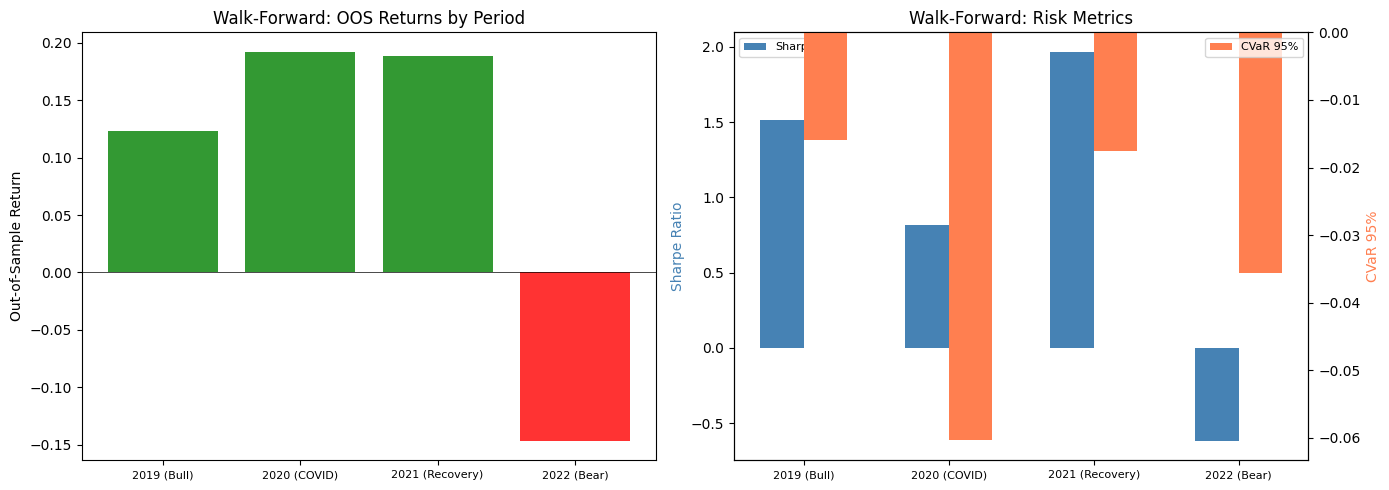

In [15]:
# Walk-Forward visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wf_names = list(wf_results.keys())
wf_returns = [wf_results[w]['total_return'] for w in wf_names]
colors = ['green' if r > 0 else 'red' for r in wf_returns]
short_names = [w.split('â†’')[1].strip()[:20] for w in wf_names]
axes[0].bar(range(len(wf_names)), wf_returns, color=colors, alpha=0.8)
axes[0].set_xticks(range(len(wf_names)))
axes[0].set_xticklabels(short_names, fontsize=8)
axes[0].set_ylabel('Out-of-Sample Return')
axes[0].set_title('Walk-Forward: OOS Returns by Period')
axes[0].axhline(0, color='black', linewidth=0.5)

sharpe_vals = [wf_results[w]['sharpe'] for w in wf_names]
cvar_vals = [wf_results[w]['cvar_95'] for w in wf_names]
x = np.arange(len(wf_names))
axes[1].bar(x - 0.15, sharpe_vals, 0.3, label='Sharpe', color='steelblue')
ax2 = axes[1].twinx()
ax2.bar(x + 0.15, cvar_vals, 0.3, label='CVaR 95%', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_names, fontsize=8)
axes[1].set_ylabel('Sharpe Ratio', color='steelblue')
ax2.set_ylabel('CVaR 95%', color='coral')
axes[1].set_title('Walk-Forward: Risk Metrics')
axes[1].legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

---
## Section 7: Lambda Ablation Study

Testing semantic penalty strength (Î = 0, 0.1, 0.5, 1.0) on the concurrent system.

In [ ]:
lambdas = [0.0, 0.1, 0.5, 1.0]
ablation_results = {}

for lam in lambdas:
    print(f"\nTraining with Î = {lam}...")
    abl_worker_envs = {}
    for profile in ['Safe', 'Neutral', 'Risky']:
        pool_tickers = risk_pools[profile]
        if len(pool_tickers) >= 2:
            abl_worker_envs[profile] = WorkerEnv(
                price_df, lexical_df, pool_tickers,
                profile=profile.lower(), window_size=30,
                lambda_penalty=lam, gamma_penalty=0.01)
    
    abl_mgr_env = ManagerEnv(price_df, lexical_df, risk_pools, window_size=30)
    abl_mgr_net, abl_w_nets, abl_hist = train_concurrent(
        abl_mgr_env, abl_worker_envs, n_episodes=100, verbose=False)
    abl_eval = evaluate_concurrent(abl_mgr_env, abl_worker_envs, abl_mgr_net, abl_w_nets, max_steps=200)
    
    ablation_results[lam] = abl_eval
    ablation_results[lam]['training_reward'] = float(abl_hist['manager_rewards'][-1])
    
    print(f"  Return={abl_eval['total_return']:.4f}, Sharpe={abl_eval['sharpe']:.4f}, "
          f"Alloc={[f'{a:.2f}' for a in abl_eval['avg_allocation']]}")

print("\nAblation Complete!")


Training with Î» = 0.0...
  Return=0.0046, Sharpe=0.1107, Alloc=['0.38', '0.35', '0.26']

Training with Î» = 0.1...
  Return=0.0094, Sharpe=0.1552, Alloc=['0.36', '0.43', '0.21']

Training with Î» = 0.5...
  Return=-0.0646, Sharpe=-0.4813, Alloc=['0.22', '0.29', '0.49']

Training with Î» = 1.0...
  Return=-0.0138, Sharpe=-0.0587, Alloc=['0.32', '0.34', '0.34']

Ablation Complete!


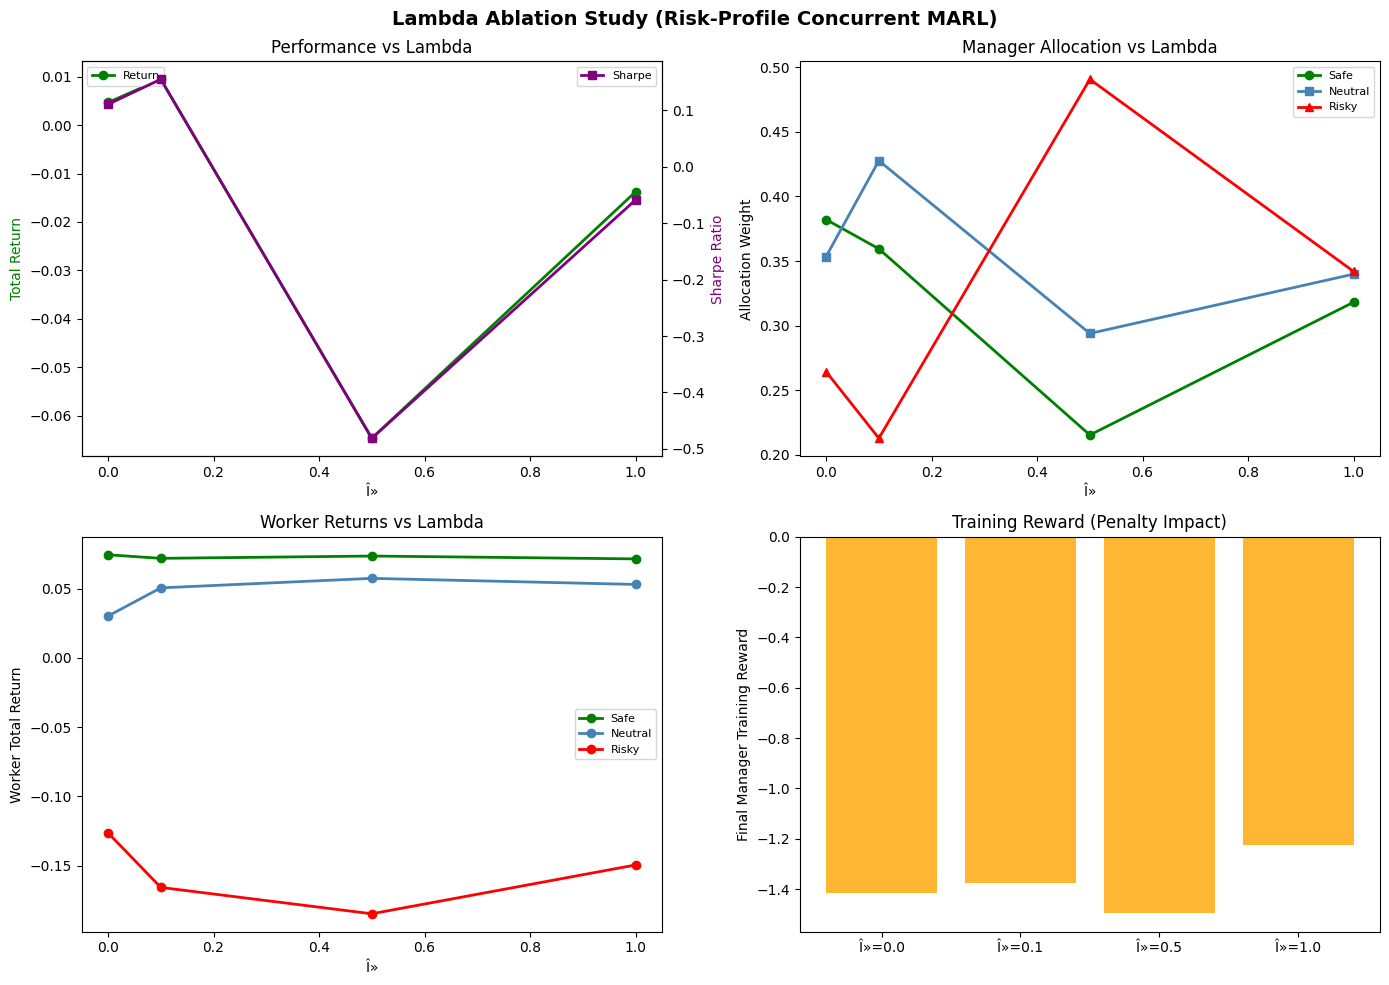

In [ ]:
# Ablation visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Lambda Ablation Study (Risk-Profile Concurrent MARL)", fontsize=14, fontweight='bold')

lam_vals = list(ablation_results.keys())

# Returns per lambda
ax = axes[0, 0]
ret_vals = [ablation_results[l]['total_return'] for l in lam_vals]
sharpe_vals = [ablation_results[l]['sharpe'] for l in lam_vals]
ax.plot(lam_vals, ret_vals, 'o-', color='green', label='Return', linewidth=2)
ax2 = ax.twinx()
ax2.plot(lam_vals, sharpe_vals, 's-', color='purple', label='Sharpe', linewidth=2)
ax.set_xlabel('Î')
ax.set_ylabel('Total Return', color='green')
ax2.set_ylabel('Sharpe Ratio', color='purple')
ax.set_title('Performance vs Lambda')
ax.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

# Allocation shifts per lambda
ax = axes[0, 1]
safe_alloc = [ablation_results[l]['avg_allocation'][0] for l in lam_vals]
neut_alloc = [ablation_results[l]['avg_allocation'][1] for l in lam_vals]
risk_alloc = [ablation_results[l]['avg_allocation'][2] for l in lam_vals]
ax.plot(lam_vals, safe_alloc, 'o-', color='green', label='Safe', linewidth=2)
ax.plot(lam_vals, neut_alloc, 's-', color='steelblue', label='Neutral', linewidth=2)
ax.plot(lam_vals, risk_alloc, '^-', color='red', label='Risky', linewidth=2)
ax.set_xlabel('Î')
ax.set_ylabel('Allocation Weight')
ax.set_title('Manager Allocation vs Lambda')
ax.legend(fontsize=8)

# Worker returns per lambda
ax = axes[1, 0]
for profile, color in [('Safe','green'), ('Neutral','steelblue'), ('Risky','red')]:
    wr = [ablation_results[l]['worker_results'][profile]['total_return'] for l in lam_vals]
    ax.plot(lam_vals, wr, 'o-', color=color, label=profile, linewidth=2)
ax.set_xlabel('Î')
ax.set_ylabel('Worker Total Return')
ax.set_title('Worker Returns vs Lambda')
ax.legend(fontsize=8)

# Training reward
ax = axes[1, 1]
train_rewards = [ablation_results[l]['training_reward'] for l in lam_vals]
ax.bar(range(len(lam_vals)), train_rewards, color='orange', alpha=0.8)
ax.set_xticks(range(len(lam_vals)))
ax.set_xticklabels([f"Î»={l}" for l in lam_vals])
ax.set_ylabel('Final Manager Training Reward')
ax.set_title('Training Reward (Penalty Impact)')

plt.tight_layout()
plt.show()

---
## Section 8: Drawdown Decomposition & Risk Summary

In [18]:
# Use baseline (Î»=0.1) evaluation for drawdown analysis
base_returns = eval_result['global_returns']
dds = drawdown_decomposition(base_returns)

print(f"Drawdown Events: {len(dds)}")
if dds:
    print(f"Max Depth: {max(d['depth'] for d in dds):.4f}")
    print(f"Avg Depth: {np.mean([d['depth'] for d in dds]):.4f}")
    print(f"Avg Duration: {np.mean([d['duration'] for d in dds]):.1f} days")
    print(f"Avg Recovery: {np.mean([d['recovery'] for d in dds]):.1f} days")

print("\n" + "=" * 50)
print("RISK METRICS SUMMARY (Concurrent System, Î»=0.1)")
print("=" * 50)
for key in ['total_return', 'sharpe', 'max_drawdown', 'cvar_95', 'sortino', 'calmar']:
    print(f"  {key:>15}: {eval_result[key]:.4f}")

Drawdown Events: 12
Max Depth: 0.1235
Avg Depth: 0.0198
Avg Duration: 14.5 days
Avg Recovery: 7.0 days

RISK METRICS SUMMARY (Concurrent System, Î»=0.1)
     total_return: 0.0215
           sharpe: 0.2595
     max_drawdown: 0.1235
          cvar_95: -0.0227
          sortino: 0.0212
           calmar: 0.3004


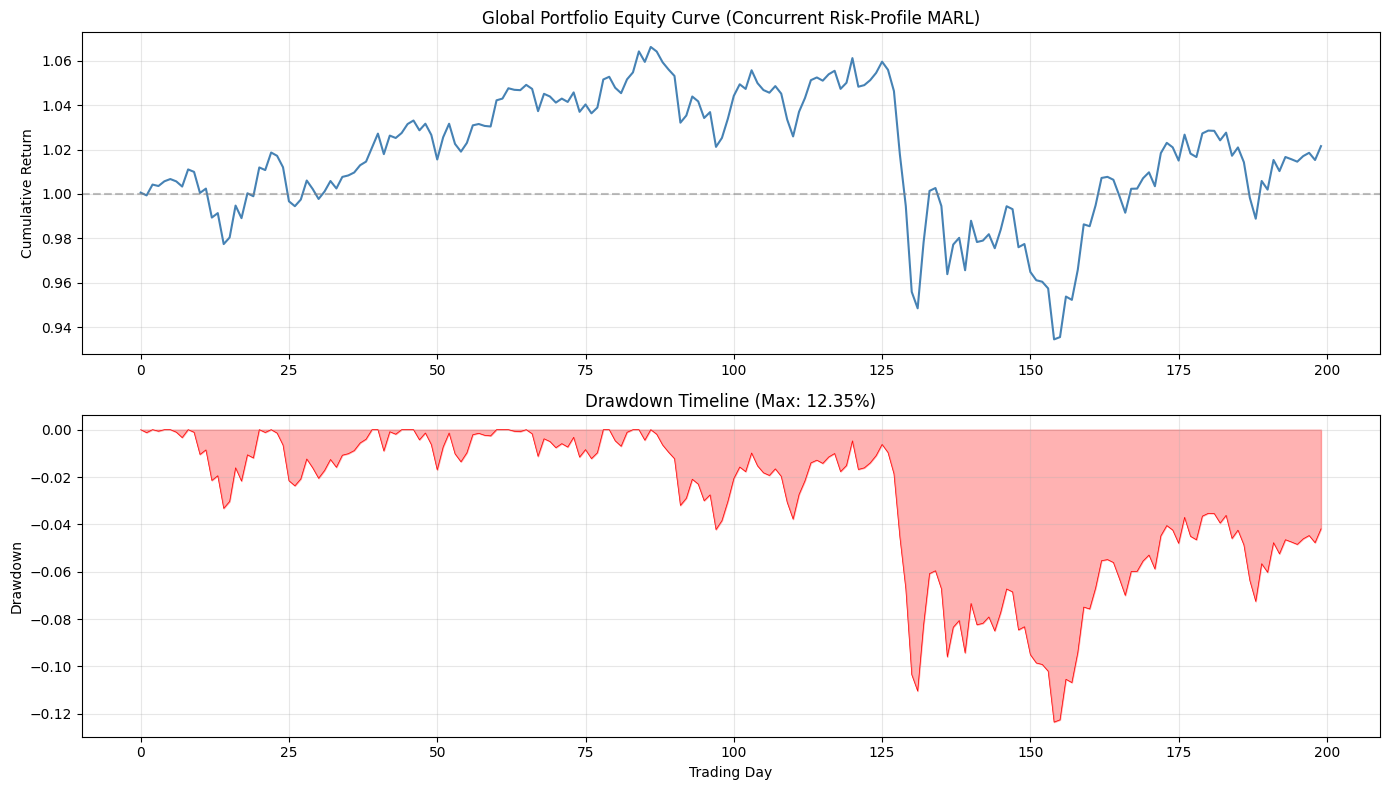

In [19]:
# Drawdown timeline
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

cum_ret = np.cumprod(1 + base_returns)
axes[0].plot(cum_ret, color='steelblue', linewidth=1.5)
axes[0].set_ylabel('Cumulative Return')
axes[0].set_title('Global Portfolio Equity Curve (Concurrent Risk-Profile MARL)')
axes[0].axhline(1.0, color='grey', linestyle='--', alpha=0.5)
axes[0].grid(alpha=0.3)

peak = np.maximum.accumulate(cum_ret)
dd_series = (peak - cum_ret) / peak
axes[1].fill_between(range(len(dd_series)), 0, -dd_series, color='red', alpha=0.3)
axes[1].plot(range(len(dd_series)), -dd_series, color='red', linewidth=0.5)
axes[1].set_xlabel('Trading Day')
axes[1].set_ylabel('Drawdown')
axes[1].set_title(f'Drawdown Timeline (Max: {eval_result["max_drawdown"]:.2%})')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 9: Results Summary

### Architecture Re-Design
- **From**: GICS sector-based Workers (1/N convergence problem)
- **To**: Risk-Profile Workers (Safe/Neutral/Risky based on historical Beta)

### Key Improvements
1. **Mathematical Divergence**: Each Worker has a unique reward function preventing convergence to identical strategies
2. **True Communication**: Manager observes Worker cumulative returns + volatility
3. **Concurrent Training**: All 4 agents step and learn simultaneously (toward MADDPG logic)



In [20]:
# Save all results
results = {
    'beta_classification': {t: {'beta': float(betas[t]), 'profile': beta_labels[t]} for t in tickers},
    'risk_pools': {k: v for k, v in risk_pools.items()},
    'global_evaluation': {k: float(v) if isinstance(v, (np.floating, float)) else v
                          for k, v in eval_result.items() 
                          if k not in ('global_returns', 'avg_allocation', 'worker_results')},
    'avg_allocation': {name: float(eval_result['avg_allocation'][i]) 
                       for i, name in enumerate(['Safe', 'Neutral', 'Risky'])},
    'worker_results': eval_result['worker_results'],
    'walk_forward': {w: {'total_return': float(ev['total_return']), 
                         'sharpe': float(ev['sharpe']),
                         'max_drawdown': float(ev['max_drawdown'])}
                     for w, ev in wf_results.items()},
    'ablation': {str(l): {'total_return': float(ev['total_return']),
                           'sharpe': float(ev['sharpe']),
                           'allocation': [float(a) for a in ev['avg_allocation']]}
                 for l, ev in ablation_results.items()},
}

with open("data/processed/sp500_notebook_results.json", "w") as f:
    json.dump(results, f, indent=2, default=str)

print("Results saved to data/processed/sp500_notebook_results.json")
print(f"\nTotal runtime: {time.time()-t0:.1f}s")

Results saved to data/processed/sp500_notebook_results.json

Total runtime: 5527.3s
